# Persistent Memory

In [1]:

from langgraph.graph import add_messages, StateGraph, END
from langgraph.checkpoint.sqlite import SqliteSaver
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
import sqlite3

In [2]:
from typing import TypedDict, Annotated
import os

In [3]:
from dotenv import load_dotenv
load_dotenv(override=True)


True

In [4]:
def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.3, max_tokens=2000
    )
llm = get_groq_llm()

## Database Initialization & Saver

In [5]:
DB_DIR = "storage" 
DB_NAME = "chatbot_chkpt.sqlite"
DB_PATH = os.path.join(DB_DIR, DB_NAME)

# 2. Safety Check: If the directory doesn't exist yet, create it programmatically
if not os.path.exists(DB_DIR):
    os.makedirs(DB_DIR)
    print(f"Created dedicated directory: ./{DB_DIR}/")

# 3. Establish the connection using the nested file path
sqlite3_conn = sqlite3.connect(DB_PATH, check_same_thread=False)
#sqlite3_conn = sqlite3.connect("chatbot_chkpt.sqlite", check_same_thread=False)
memory = SqliteSaver(sqlite3_conn)

Created dedicated directory: ./storage/


In [6]:
class SQLChatState(TypedDict):
    messages: Annotated[list, add_messages]

In [7]:
def chat_bot(state: SQLChatState):
    return {
        "messages": llm.invoke(state['messages'])
    }

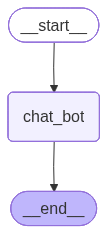

In [8]:
graph = StateGraph(SQLChatState)
graph.add_node('chat_bot', chat_bot)
graph.add_edge('chat_bot', END)
graph.set_entry_point('chat_bot')
graph.compile(checkpointer=memory)


In [9]:
app = graph.compile(checkpointer=memory)

In [10]:
config = {
    'configurable': {
        'thread_id': 2
    }
}

In [11]:
def chat():
    while True:
        user_input = input("User <exit | end>: ")
        if user_input in ['exit', 'end']:
            break
        result = app.invoke({
            'messages': [HumanMessage(content=user_input)]
            },
            config=config
        )
        print("User: " + user_input)
        print("AI: " + result['messages'][-1].content, end='\n\n')

In [12]:
chat()

User: Hello!
AI: Hello! 👋 How can I help you today?

User: My name is Vignesh
AI: Nice to meet you, Vignesh! How can I help you today?



In [13]:
chat()

User: What is my name?
AI: Your name is Vignesh.

